# GROUP Section 1-2: FIA Data Preprocessing and Exploration

        This official group notebook consolidates the corrected Section 1 and Section 2 workflow for the COMM074 FIA tree carbon storage project.

        It inventories the original FIA DataMart files, selects relevant tables, extracts selected-state data, merges TREE/PLOT/COND, cleans the tree-level dataset, performs EDA, engineers features, removes leakage-risk variables and creates the final train/validation/test datasets.

        No machine learning models are trained here. Encoding, scaling, imputation and model fitting should be performed later in model-specific notebooks using training-data-only pipelines.


## 1. Import libraries and project paths


In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.paths import RAW_DIR, INVENTORY_DIR, PARQUET_DIR, INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, OUTPUTS_DIR, create_project_dirs
from src.fia_inventory import create_file_inventory, create_table_columns_file
from src.fia_extract import extract_core_tables
from src.fia_merge import load_extracted_tables, validate_required_columns, merge_tree_plot_cond
from src.fia_cleaning import (
    load_merged_dataset,
    summarise_missing_values,
    clean_fia_tree_data,
    summarise_key_variables,
    save_cleaning_outputs,
    convert_key_columns_to_numeric,
)
from src.fia_eda import (
    create_eda_sample,
    save_dataset_summary,
    create_numeric_summary,
    create_categorical_summary,
    create_state_summary,
    create_species_summary,
    create_forest_type_summary,
    plot_missing_values,
    plot_carbon_distribution,
    plot_log_carbon_distribution,
    plot_dia_vs_carbon,
    plot_ht_vs_carbon,
    plot_cr_vs_carbon,
    plot_carbon_by_state,
    plot_carbon_by_top_species,
    plot_carbon_by_forest_type,
    plot_carbon_by_diameter_class,
    plot_correlation_heatmap,
)
from src.fia_preprocessing import (
    create_engineered_features,
    select_final_model_columns,
    create_stratified_regression_split,
    create_final_data_dictionary,
    save_preprocessing_outputs,
)

create_project_dirs()

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)
print("Inventory folder:", INVENTORY_DIR)
print("Parquet folder:", PARQUET_DIR)
print("Interim folder:", INTERIM_DIR)
print("Processed folder:", PROCESSED_DIR)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)



Project root: e:\BA_DV_Project\COMM074_FIA_Project
Raw data folder: E:\BA_DV_Project\COMM074_FIA_Project\data\raw_entire_fia
Inventory folder: E:\BA_DV_Project\COMM074_FIA_Project\data\inventory
Parquet folder: E:\BA_DV_Project\COMM074_FIA_Project\data\parquet
Interim folder: E:\BA_DV_Project\COMM074_FIA_Project\data\interim
Processed folder: E:\BA_DV_Project\COMM074_FIA_Project\data\processed
Figures folder: E:\BA_DV_Project\COMM074_FIA_Project\figures
Outputs folder: E:\BA_DV_Project\COMM074_FIA_Project\outputs


## 2. Raw FIA file inventory and table selection

        The raw FIA inventory reads filenames and CSV headers only. It does not load the large FIA CSV files into memory.


In [2]:
raw_entire_files = sorted(RAW_DIR.glob("ENTIRE_*.csv"))
print("Number of ENTIRE_*.csv files found:", len(raw_entire_files))

if not raw_entire_files:
    raise FileNotFoundError(
        "No ENTIRE_*.csv files were found in data/raw_entire_fia/. "
        "Please place the raw FIA DataMart CSV files in that folder before running this notebook."
    )
else:
    print("Raw ENTIRE_*.csv file guard passed.")



Number of ENTIRE_*.csv files found: 111
Raw ENTIRE_*.csv file guard passed.


In [3]:
file_inventory = create_file_inventory(
    raw_dir=RAW_DIR,
    output_path=INVENTORY_DIR / "fia_file_inventory.csv",
)

file_inventory.sort_values("file_size_mb", ascending=False).head(20)



,file_name,file_size_mb,n_columns,columns_preview
102,ENTIRE_TREE_GRM_ESTN.csv,13956.027905,45,"CN, STATECD, INVYR, PLT_CN, TRE_CN, LAND_BASIS..."
99,ENTIRE_TREE.csv,12745.042995,198,"CN, PLT_CN, PREV_TRE_CN, INVYR, STATECD, UNITC..."
19,ENTIRE_FVS_TREEINIT_COND.csv,5482.998530,53,"STAND_CN, STAND_ID, PLOT_CN, STANDPLOT_CN, STA..."
20,ENTIRE_FVS_TREEINIT_PLOT.csv,5368.929459,53,"STAND_CN, STAND_ID, PLOT_CN, STANDPLOT_CN, STA..."
101,ENTIRE_TREE_GRM_COMPONENT.csv,4846.041245,78,"TRE_CN, PREV_TRE_CN, PLT_CN, STATECD, DIA_BEGI..."
103,ENTIRE_TREE_GRM_MIDPT.csv,4399.661486,68,"TRE_CN, PREV_TRE_CN, PLT_CN, STATECD, SUBPTYP,..."
100,ENTIRE_TREE_GRM_BEGIN.csv,4078.749263,68,"TRE_CN, PREV_TRE_CN, PLT_CN, STATECD, SUBPTYP,..."
38,ENTIRE_PLOTSNAP.csv,3218.383060,89,"CN, SRV_CN, CTY_CN, PREV_PLT_CN, INVYR, STATEC..."
16,ENTIRE_FVS_PLOTINIT_PLOT.csv,3119.162166,80,"STAND_CN, STAND_ID, STANDPLOT_CN, STANDPLOT_ID..."
44,ENTIRE_POP_PLOT_STRATUM_ASSGN.csv,2256.459531,14,"CN, STRATUM_CN, PLT_CN, STATECD, INVYR, UNITCD..."


In [4]:
table_columns = create_table_columns_file(
    raw_dir=RAW_DIR,
    output_path=INVENTORY_DIR / "fia_table_columns.csv",
)

table_columns.head(20)



,file_name,column_position,column_name
0,ENTIRE_BEGINEND.csv,1,ONEORTWO
1,ENTIRE_BEGINEND.csv,2,CREATED_DATE
2,ENTIRE_BEGINEND.csv,3,MODIFIED_DATE
3,ENTIRE_COND.csv,1,CN
4,ENTIRE_COND.csv,2,PLT_CN
5,ENTIRE_COND.csv,3,INVYR
6,ENTIRE_COND.csv,4,STATECD
7,ENTIRE_COND.csv,5,UNITCD
8,ENTIRE_COND.csv,6,COUNTYCD
9,ENTIRE_COND.csv,7,PLOT


In [5]:
dataset_scope_summary = pd.DataFrame([
    {"item": "Raw data source", "value": "USDA Forest Service FIA DataMart ENTIRE CSV database"},
    {"item": "Main modelling unit", "value": "One individual tree"},
    {"item": "Main target variable", "value": "CARBON_AG"},
    {"item": "Core tables selected", "value": "TREE, PLOT, COND"},
    {"item": "Reference tables selected", "value": "Species, species group, forest type, forest type group, county, ownership group"},
    {"item": "Excluded table families", "value": "DWM, ozone, lichen, vegetation, FVS, POP and EVALIDATOR tables"},
])

display(dataset_scope_summary)

selection_decisions = pd.DataFrame([
    {"file_name": "ENTIRE_TREE.csv", "include_for_project": "Yes", "reason": "Main individual-tree table containing measurements and the CARBON_AG target."},
    {"file_name": "ENTIRE_PLOT.csv", "include_for_project": "Yes", "reason": "Provides plot-level geography and inventory context."},
    {"file_name": "ENTIRE_COND.csv", "include_for_project": "Yes", "reason": "Provides forest condition, stand, site and ownership variables."},
    {"file_name": "ENTIRE_REF_SPECIES.csv", "include_for_project": "Yes", "reason": "Provides species labels for interpreting SPCD."},
    {"file_name": "ENTIRE_REF_SPECIES_GROUP.csv", "include_for_project": "Yes", "reason": "Provides species group labels for interpretation."},
    {"file_name": "ENTIRE_REF_FOREST_TYPE.csv", "include_for_project": "Yes", "reason": "Provides forest type labels for EDA and reporting."},
    {"file_name": "ENTIRE_REF_FOREST_TYPE_GROUP.csv", "include_for_project": "Yes", "reason": "Provides broader forest type group labels."},
    {"file_name": "ENTIRE_COUNTY.csv", "include_for_project": "Yes", "reason": "Provides county and state context."},
    {"file_name": "ENTIRE_REF_OWNGRPCD.csv", "include_for_project": "Yes", "reason": "Provides ownership group labels for interpretation."},
])

selection_decisions.to_csv(OUTPUTS_DIR / "table_selection_decisions.csv", index=False)
selection_decisions



,item,value
0,Raw data source,USDA Forest Service FIA DataMart ENTIRE CSV da...
1,Main modelling unit,One individual tree
2,Main target variable,CARBON_AG
3,Core tables selected,"TREE, PLOT, COND"
4,Reference tables selected,"Species, species group, forest type, forest ty..."
5,Excluded table families,"DWM, ozone, lichen, vegetation, FVS, POP and E..."


,file_name,include_for_project,reason
0,ENTIRE_TREE.csv,Yes,Main individual-tree table containing measurem...
1,ENTIRE_PLOT.csv,Yes,Provides plot-level geography and inventory co...
2,ENTIRE_COND.csv,Yes,"Provides forest condition, stand, site and own..."
3,ENTIRE_REF_SPECIES.csv,Yes,Provides species labels for interpreting SPCD.
4,ENTIRE_REF_SPECIES_GROUP.csv,Yes,Provides species group labels for interpretation.
5,ENTIRE_REF_FOREST_TYPE.csv,Yes,Provides forest type labels for EDA and report...
6,ENTIRE_REF_FOREST_TYPE_GROUP.csv,Yes,Provides broader forest type group labels.
7,ENTIRE_COUNTY.csv,Yes,Provides county and state context.
8,ENTIRE_REF_OWNGRPCD.csv,Yes,Provides ownership group labels for interpreta...


## 3. Validate required raw files


In [6]:
required_raw_files = [
    "ENTIRE_TREE.csv",
    "ENTIRE_PLOT.csv",
    "ENTIRE_COND.csv",
    "ENTIRE_REF_SPECIES.csv",
    "ENTIRE_REF_SPECIES_GROUP.csv",
    "ENTIRE_REF_FOREST_TYPE.csv",
    "ENTIRE_REF_FOREST_TYPE_GROUP.csv",
    "ENTIRE_COUNTY.csv",
    "ENTIRE_REF_OWNGRPCD.csv",
]

for file in required_raw_files:
    path = RAW_DIR / file
    print(file, "FOUND" if path.exists() else "MISSING")

missing_raw_files = [
    file for file in required_raw_files
    if not (RAW_DIR / file).exists()
]

if missing_raw_files:
    raise FileNotFoundError(
        "The following required raw FIA files are missing from data/raw_entire_fia/: "
        + ", ".join(missing_raw_files)
    )
else:
    print("All required raw FIA files are present.")



ENTIRE_TREE.csv FOUND
ENTIRE_PLOT.csv FOUND
ENTIRE_COND.csv FOUND
ENTIRE_REF_SPECIES.csv FOUND
ENTIRE_REF_SPECIES_GROUP.csv FOUND
ENTIRE_REF_FOREST_TYPE.csv FOUND
ENTIRE_REF_FOREST_TYPE_GROUP.csv FOUND
ENTIRE_COUNTY.csv FOUND
ENTIRE_REF_OWNGRPCD.csv FOUND
All required raw FIA files are present.


## 4. Selected states for proof-of-concept extraction


In [7]:
selected_state_codes = [1, 6, 13, 23, 41, 53]

selected_states_table = pd.DataFrame([
    {"STATECD": 1, "state_name": "Alabama", "region_reason": "Southeastern forest context"},
    {"STATECD": 6, "state_name": "California", "region_reason": "Western forest context"},
    {"STATECD": 13, "state_name": "Georgia", "region_reason": "Southeastern forest context"},
    {"STATECD": 23, "state_name": "Maine", "region_reason": "Northeastern forest context"},
    {"STATECD": 41, "state_name": "Oregon", "region_reason": "Pacific Northwest forest context"},
    {"STATECD": 53, "state_name": "Washington", "region_reason": "Pacific Northwest forest context"},
])

selected_states_table



,STATECD,state_name,region_reason
0,1,Alabama,Southeastern forest context
1,6,California,Western forest context
2,13,Georgia,Southeastern forest context
3,23,Maine,Northeastern forest context
4,41,Oregon,Pacific Northwest forest context
5,53,Washington,Pacific Northwest forest context


The six selected states provide a manageable proof-of-concept dataset while retaining regional variation across the Southeast, Northeast, Western United States and Pacific Northwest.


## 5. Extract selected FIA tables to Parquet


In [8]:
extraction_summary = extract_core_tables(
    selected_state_codes=selected_state_codes
)

extraction_summary



Checking columns in ENTIRE_PLOT.csv
plot_selected: 246,218 rows
Checking columns in ENTIRE_TREE.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

tree_selected: 5,796,627 rows
Checking columns in ENTIRE_COND.csv
cond_selected: 311,972 rows
Checking columns in ENTIRE_REF_SPECIES.csv
ref_species: 2,697 rows
Checking columns in ENTIRE_REF_SPECIES_GROUP.csv
ref_species_group: 54 rows
Checking columns in ENTIRE_REF_FOREST_TYPE.csv
ref_forest_type: 207 rows
Checking columns in ENTIRE_REF_FOREST_TYPE_GROUP.csv
ref_forest_type_group: 34 rows
Checking columns in ENTIRE_COUNTY.csv
county: 3,250 rows
Checking columns in ENTIRE_REF_OWNGRPCD.csv
ref_owngrpcd: 4 rows
Extraction summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\extraction_summary.csv


,table_name,output_file,row_count
0,plot_selected,plot_selected.parquet,246218
1,tree_selected,tree_selected.parquet,5796627
2,cond_selected,cond_selected.parquet,311972
3,ref_species,ref_species.parquet,2697
4,ref_species_group,ref_species_group.parquet,54
5,ref_forest_type,ref_forest_type.parquet,207
6,ref_forest_type_group,ref_forest_type_group.parquet,34
7,county,county.parquet,3250
8,ref_owngrpcd,ref_owngrpcd.parquet,4


## 6. Validate extracted Parquet files


In [9]:
# This cell is intentionally self-contained so it can be rerun safely.
if "PARQUET_DIR" not in globals():
    import sys
    from pathlib import Path

    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    sys.path.append(str(PROJECT_ROOT))

    from src.paths import PARQUET_DIR

required_parquet_files = [
    "tree_selected.parquet",
    "plot_selected.parquet",
    "cond_selected.parquet",
]

print("Checking extracted Parquet folder:", PARQUET_DIR)

for file in required_parquet_files:
    path = PARQUET_DIR / file
    print(file, "FOUND" if path.exists() else "MISSING")

missing_parquet_files = [
    file for file in required_parquet_files
    if not (PARQUET_DIR / file).exists()
]

if missing_parquet_files:
    raise FileNotFoundError(
        "The following required extracted Parquet files are missing from data/parquet/: "
        + ", ".join(missing_parquet_files)
        + ". Please run the extraction step before continuing."
    )
else:
    print("All required extracted Parquet files are present.")


Checking extracted Parquet folder: E:\BA_DV_Project\COMM074_FIA_Project\data\parquet
tree_selected.parquet FOUND
plot_selected.parquet FOUND
cond_selected.parquet FOUND
All required extracted Parquet files are present.


In [10]:
plot_selected = pd.read_parquet(PARQUET_DIR / "plot_selected.parquet")
tree_selected = pd.read_parquet(PARQUET_DIR / "tree_selected.parquet")
cond_selected = pd.read_parquet(PARQUET_DIR / "cond_selected.parquet")

print("Plot shape:", plot_selected.shape)
print("Tree shape:", tree_selected.shape)
print("Condition shape:", cond_selected.shape)

extraction_validation = pd.DataFrame([
    {"table": "PLOT", "rows": len(plot_selected), "columns": plot_selected.shape[1]},
    {"table": "TREE", "rows": len(tree_selected), "columns": tree_selected.shape[1]},
    {"table": "COND", "rows": len(cond_selected), "columns": cond_selected.shape[1]},
])

extraction_validation.to_csv(OUTPUTS_DIR / "extraction_validation_summary.csv", index=False)
extraction_validation



Plot shape: (246218, 13)
Tree shape: (5796627, 28)
Condition shape: (311972, 14)


,table,rows,columns
0,PLOT,246218,13
1,TREE,5796627,28
2,COND,311972,14


In [11]:
print("PLOT selected states:")
display(plot_selected["STATECD"].value_counts().sort_index())

print("TREE selected states:")
display(tree_selected["STATECD"].value_counts().sort_index())

unexpected_plot_states = sorted(set(plot_selected["STATECD"].dropna().unique()) - set(selected_state_codes))
unexpected_tree_states = sorted(set(tree_selected["STATECD"].dropna().unique()) - set(selected_state_codes))

print("Unexpected PLOT states:", unexpected_plot_states)
print("Unexpected TREE states:", unexpected_tree_states)

if unexpected_plot_states or unexpected_tree_states:
    raise ValueError("Unexpected state codes found after extraction.")



PLOT selected states:


STATECD
1     42677
6     43814
13    73796
23    21638
41    41194
53    23099
Name: count, dtype: int64

TREE selected states:


STATECD
1     1115757
6      446320
13    1880767
23    1030866
41     791427
53     531490
Name: count, dtype: int64

Unexpected PLOT states: []
Unexpected TREE states: []


## 7. Preview extracted tables and initial missingness


In [12]:
display(plot_selected.head())
display(tree_selected.head())
display(cond_selected.head())

required_tree_cols = ["PLT_CN", "CONDID", "SPCD", "DIA", "HT", "ACTUALHT", "CR", "CARBON_AG"]
key_tree_cols = [c for c in required_tree_cols if c in tree_selected.columns]

tree_selected[key_tree_cols].isna().mean().mul(100).round(2).sort_values(ascending=False)



,CN,STATECD,UNITCD,COUNTYCD,PLOT,PLOT_STATUS_CD,INVYR,MEASYEAR,MEASMON,MEASDAY,LAT,LON,ELEV
0,11839,6,1,15,1,1.0,1994,1991.0,7.0,15.0,41.478172,-123.946777,1300.0
1,11840,6,1,15,2,1.0,1994,1991.0,6.0,15.0,41.473110,-123.964241,800.0
2,11841,6,1,15,3,1.0,1994,1991.0,6.0,15.0,41.507778,-124.078056,1100.0
3,11842,6,1,15,4,1.0,1994,1991.0,7.0,15.0,41.570831,-123.896393,2200.0
4,11843,6,1,15,5,1.0,1994,1991.0,6.0,15.0,41.543613,-124.029449,1500.0


,CN,PLT_CN,PREV_TRE_CN,INVYR,STATECD,UNITCD,COUNTYCD,PLOT,SUBP,TREE,...,CR,CCLCD,CARBON_AG,CARBON_BG,DRYBIO_AG,DRYBIO_BG,VOLCFNET,VOLCSNET,VOLBFNET,TPA_UNADJ
0,157582492010854,157499429010854,NaN,1972,1,1,3,90013,102,3,...,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,5.533
1,157582493010854,157499429010854,NaN,1972,1,1,3,90013,103,1,...,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,4.301
2,157582494010854,157499429010854,NaN,1972,1,1,3,90013,105,1,...,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,20.693
3,157582495010854,157499429010854,NaN,1972,1,1,3,90013,105,3,...,NaN,NaN,0.000000,0.00000,NaN,NaN,NaN,NaN,NaN,3.922
4,157582496010854,157499429010854,NaN,1972,1,1,3,90013,105,4,...,NaN,4.0,2.064865,0.60393,4.12973,1.20786,NaN,0.0,0.0,0.000


,CN,PLT_CN,CONDID,COND_STATUS_CD,FORTYPCD,FLDTYPCD,OWNGRPCD,RESERVCD,SITECLCD,STDAGE,STDSZCD,BALIVE,ALSTK,GSSTK
0,15377900010497,40225347010497,1,1,225.0,225.0,10.0,0.0,6.0,150.0,1.0,110.3308,50.6769,50.6769
1,15323372010497,40218192010497,1,1,924.0,924.0,40.0,0.0,7.0,NaN,2.0,54.3637,43.0943,43.0943
2,15377732010497,40218141010497,1,1,225.0,225.0,10.0,1.0,6.0,104.0,1.0,108.1716,47.2517,47.2517
3,15386113010497,40218171010497,1,1,281.0,281.0,10.0,1.0,7.0,154.0,1.0,157.4262,45.8306,45.8306
4,15000836010497,40218106010497,1,2,NaN,NaN,40.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


ACTUALHT     31.18
CR           29.10
HT           18.25
CARBON_AG    12.75
DIA           5.03
SPCD          0.00
PLT_CN        0.00
CONDID        0.00
dtype: float64

Missing values are expected in several FIA measurement fields and are not treated during extraction. Essential-field cleaning is handled after the merge.


## 8. Merge TREE, PLOT and COND tables


In [13]:
tree, plot, cond = load_extracted_tables()

required_tree_cols = ["CN", "PLT_CN", "CONDID", "TREE", "STATUSCD", "SPCD", "DIA", "HT", "ACTUALHT", "CR", "CARBON_AG"]
required_plot_cols = ["CN", "STATECD", "COUNTYCD", "INVYR"]
required_cond_cols = ["PLT_CN", "CONDID", "FORTYPCD", "OWNGRPCD", "SITECLCD", "STDAGE", "STDSZCD"]

missing_tree = validate_required_columns(tree, required_tree_cols, "TREE")
missing_plot = validate_required_columns(plot, required_plot_cols, "PLOT")
missing_cond = validate_required_columns(cond, required_cond_cols, "COND")

print("Missing TREE columns:", missing_tree)
print("Missing PLOT columns:", missing_plot)
print("Missing COND columns:", missing_cond)

if missing_tree or missing_plot or missing_cond:
    raise ValueError(
        "Required columns are missing. "
        f"TREE missing: {missing_tree}; "
        f"PLOT missing: {missing_plot}; "
        f"COND missing: {missing_cond}"
    )
else:
    print("All required columns are available for merging.")



TREE has all required columns.
PLOT has all required columns.
COND has all required columns.
Missing TREE columns: []
Missing PLOT columns: []
Missing COND columns: []
All required columns are available for merging.


In [14]:
duplicate_plot_keys = plot["CN"].duplicated().sum()
duplicate_cond_keys = cond[["PLT_CN", "CONDID"]].duplicated().sum()

print("Duplicate PLOT CN keys:", duplicate_plot_keys)
print("Duplicate COND PLT_CN + CONDID keys:", duplicate_cond_keys)

if duplicate_plot_keys > 0 or duplicate_cond_keys > 0:
    raise ValueError(
        "Duplicate join keys detected. "
        f"Duplicate PLOT CN keys: {duplicate_plot_keys}; "
        f"Duplicate COND PLT_CN + CONDID keys: {duplicate_cond_keys}. "
        "Fix duplicate keys before merging to avoid row multiplication."
    )
else:
    print("Join keys are unique. Safe to proceed with merge.")



Duplicate PLOT CN keys: 0
Duplicate COND PLT_CN + CONDID keys: 0
Join keys are unique. Safe to proceed with merge.


In [15]:
merged_df, merge_summary = merge_tree_plot_cond()

print("Original TREE rows:", len(tree))
print("Merged rows:", len(merged_df))
print("Row count difference:", len(merged_df) - len(tree))

row_count_difference = len(merged_df) - len(tree)

if row_count_difference != 0:
    raise ValueError(
        f"Merged row count differs from TREE row count by {row_count_difference}. "
        "The merge may have duplicated or dropped tree records."
    )
else:
    print("Merge row count validation passed: one merged row per original TREE record.")

merge_summary



TREE has all required columns.
PLOT has all required columns.
COND has all required columns.
TREE rows before merge: 5,796,627
PLOT rows before merge: 246,218
COND rows before merge: 311,972
Rows after TREE-PLOT merge: 5,796,627
Rows after COND merge: 5,796,627
Merged dataset saved to E:\BA_DV_Project\COMM074_FIA_Project\data\interim\merged_tree_plot_cond.parquet
Merge summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\merge_summary.csv
Merged column summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\merged_column_summary.csv
Original TREE rows: 5796627
Merged rows: 5796627
Row count difference: 0
Merge row count validation passed: one merged row per original TREE record.


,metric,value
0,tree_rows_before_merge,5796627
1,plot_rows_before_merge,246218
2,cond_rows_before_merge,311972
3,rows_after_tree_plot_merge,5796627
4,rows_after_cond_merge,5796627
5,final_row_count_matches_tree,True
6,missing_plot_match_rate,0.0
7,missing_cond_match_rate,0.015009
8,plot_statecd_missing_rate,0.0
9,cond_fortypcd_missing_rate,0.015009


In [16]:
merged_state_summary = (
    merged_df["STATECD"]
    .value_counts()
    .sort_index()
    .rename_axis("STATECD")
    .reset_index(name="row_count")
)

merged_state_summary.to_csv(OUTPUTS_DIR / "merged_state_summary.csv", index=False)
merged_state_summary



,STATECD,row_count
0,1,1115757
1,6,446320
2,13,1880767
3,23,1030866
4,41,791427
5,53,531490


## 9. Clean merged tree-level data


In [17]:
merged_df = load_merged_dataset()
merged_df = convert_key_columns_to_numeric(merged_df)

numeric_conversion_cols = [
    "CARBON_AG", "DIA", "HT", "ACTUALHT", "CR",
    "STDAGE", "BALIVE", "ALSTK", "GSSTK"
]

merged_df[[c for c in numeric_conversion_cols if c in merged_df.columns]].dtypes



CARBON_AG    float64
DIA          float64
HT           float64
ACTUALHT     float64
CR           float64
STDAGE       float64
BALIVE       float64
ALSTK        float64
GSSTK        float64
dtype: object

In [18]:
target_col = "CARBON_AG"

initial_missing_summary = summarise_missing_values(merged_df)
display(initial_missing_summary.head(30))

target_summary = pd.DataFrame({
    "metric": ["row_count", "missing_count", "missing_percentage", "negative_count", "zero_count", "min", "median", "mean", "max"],
    "value": [
        len(merged_df),
        merged_df[target_col].isna().sum(),
        merged_df[target_col].isna().mean() * 100,
        (merged_df[target_col] < 0).sum(),
        (merged_df[target_col] == 0).sum(),
        merged_df[target_col].min(),
        merged_df[target_col].median(),
        merged_df[target_col].mean(),
        merged_df[target_col].max(),
    ],
})

target_summary.to_csv(OUTPUTS_DIR / "target_summary.csv", index=False)
target_summary



,variable,missing_count,missing_percentage,dtype
0,VOLBFNET,3992603,68.878039,float64
1,VOLCSNET,3992575,68.877556,float64
2,PREV_TRE_CN,3217556,55.507384,str
3,VOLCFNET,1952128,33.676964,float64
4,ACTUALHT,1807523,31.182324,float64
5,HTCD,1706518,29.439845,str
6,CR,1686578,29.095852,float64
7,FLDTYPCD,1329728,22.939685,str
8,CCLCD,1270533,21.918488,float64
9,BALIVE,1155702,19.937491,float64


,metric,value
0,row_count,5.796627e+06
1,missing_count,7.389230e+05
2,missing_percentage,1.274747e+01
3,negative_count,0.000000e+00
4,zero_count,1.588150e+05
5,min,0.000000e+00
6,median,9.036593e+01
7,mean,4.813652e+02
8,max,1.804221e+05


In [19]:
validity_checks = {}

if "DIA" in merged_df.columns:
    validity_checks["missing_DIA"] = merged_df["DIA"].isna().sum()
    validity_checks["DIA_less_equal_zero"] = (merged_df["DIA"] <= 0).sum()
if "HT" in merged_df.columns:
    validity_checks["missing_HT"] = merged_df["HT"].isna().sum()
    validity_checks["HT_less_equal_zero"] = (merged_df["HT"] <= 0).sum()
if "ACTUALHT" in merged_df.columns:
    validity_checks["missing_ACTUALHT"] = merged_df["ACTUALHT"].isna().sum()
    validity_checks["ACTUALHT_less_equal_zero"] = (merged_df["ACTUALHT"] <= 0).sum()
if "CR" in merged_df.columns:
    validity_checks["missing_CR"] = merged_df["CR"].isna().sum()
    validity_checks["CR_less_zero"] = (merged_df["CR"] < 0).sum()
    validity_checks["CR_greater_100"] = (merged_df["CR"] > 100).sum()

validity_df = pd.DataFrame(list(validity_checks.items()), columns=["check", "count"])
validity_df.to_csv(OUTPUTS_DIR / "biological_validity_checks_before_cleaning.csv", index=False)
validity_df



,check,count
0,missing_DIA,291608
1,DIA_less_equal_zero,0
2,missing_HT,1057730
3,HT_less_equal_zero,1
4,missing_ACTUALHT,1807523
5,ACTUALHT_less_equal_zero,2
6,missing_CR,1686578
7,CR_less_zero,0
8,CR_greater_100,0


In [20]:
if "STATUSCD" in merged_df.columns:
    display(merged_df["STATUSCD"].value_counts(dropna=False).sort_index())

cleaned_df, cleaning_summary = clean_fia_tree_data(
    merged_df,
    target_col=target_col,
    keep_live_only=True,
)

cleaning_summary



STATUSCD
0     116563
1    4659376
2     923820
3      96868
Name: count, dtype: int64

,step,rows_before,rows_after,rows_removed,percentage_removed,reason
0,Start,5796627,5796627,0,0.000000,Start with merged dataset.
1,Remove missing target,5796627,5057704,738923,12.747465,Remove rows where CARBON_AG is missing.
2,Remove negative target,5057704,5057704,0,0.000000,Remove rows where CARBON_AG is negative.
3,Remove missing DIA,5057704,5057704,0,0.000000,Remove rows where tree diameter is missing.
4,Remove DIA <= 0,5057704,5057704,0,0.000000,Remove rows where tree diameter is zero or neg...
5,Remove missing SPCD,5057704,5057704,0,0.000000,Remove rows where species code is missing.
6,Keep live trees only,5057704,4540549,517155,10.225094,Keep only rows where STATUSCD equals 1.
7,Remove exact duplicate rows,4540549,4540549,0,0.000000,Remove rows that are exact duplicates across a...


In [21]:
coded_missing_values = [-999, -99, -9]
coded_missing_cols = ["STDAGE", "BALIVE", "ALSTK", "GSSTK"]

coded_missing_replacement_summary = []

for col in coded_missing_cols:
    if col in cleaned_df.columns:
        before_count = cleaned_df[col].isin(coded_missing_values).sum()
        cleaned_df[col] = cleaned_df[col].replace(coded_missing_values, np.nan)
        after_count = cleaned_df[col].isin(coded_missing_values).sum()
        coded_missing_replacement_summary.append({
            "variable": col,
            "coded_missing_values_checked": coded_missing_values,
            "coded_missing_count_before": before_count,
            "coded_missing_count_after": after_count,
        })

coded_missing_replacement_summary = pd.DataFrame(coded_missing_replacement_summary)
coded_missing_replacement_summary.to_csv(OUTPUTS_DIR / "coded_missing_replacement_summary.csv", index=False)
coded_missing_replacement_summary



,variable,coded_missing_values_checked,coded_missing_count_before,coded_missing_count_after
0,STDAGE,"[-999, -99, -9]",35225,0
1,BALIVE,"[-999, -99, -9]",0,0
2,ALSTK,"[-999, -99, -9]",0,0
3,GSSTK,"[-999, -99, -9]",0,0


In [22]:
post_clean_checks = {
    "missing_target": cleaned_df[target_col].isna().sum(),
    "negative_target": (cleaned_df[target_col] < 0).sum(),
    "zero_target": (cleaned_df[target_col] == 0).sum(),
    "missing_DIA": cleaned_df["DIA"].isna().sum(),
    "DIA_less_equal_zero": (cleaned_df["DIA"] <= 0).sum(),
    "missing_SPCD": cleaned_df["SPCD"].isna().sum(),
}

if "STATUSCD" in cleaned_df.columns:
    post_clean_checks["non_live_status_count"] = (cleaned_df["STATUSCD"] != 1).sum()

display(pd.DataFrame(list(post_clean_checks.items()), columns=["check", "count"]))

print("STDAGE minimum after coded missing replacement:", cleaned_df["STDAGE"].min())
print("Remaining coded missing STDAGE values:", cleaned_df["STDAGE"].isin([-999, -99, -9]).sum())

if cleaned_df["STDAGE"].isin([-999, -99, -9]).sum() > 0:
    raise ValueError("Coded missing STDAGE values remain after replacement.")



,check,count
0,missing_target,0
1,negative_target,0
2,zero_target,0
3,missing_DIA,0
4,DIA_less_equal_zero,0
5,missing_SPCD,0
6,non_live_status_count,0


STDAGE minimum after coded missing replacement: 0.0
Remaining coded missing STDAGE values: 0


In [23]:
post_missing_summary = summarise_missing_values(cleaned_df)
key_variable_summary = summarise_key_variables(cleaned_df, target_col=target_col)

save_cleaning_outputs(
    cleaned_df=cleaned_df,
    cleaning_summary=cleaning_summary,
    missing_summary=post_missing_summary,
    key_summary=key_variable_summary,
)

reloaded_cleaned = pd.read_parquet(INTERIM_DIR / "fia_tree_carbon_clean_unencoded.parquet")
print("Reloaded shape:", reloaded_cleaned.shape)
print("Matches cleaned_df shape:", reloaded_cleaned.shape == cleaned_df.shape)



Cleaned dataset saved to E:\BA_DV_Project\COMM074_FIA_Project\data\interim\fia_tree_carbon_clean_unencoded.parquet
Cleaning summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\cleaning_summary.csv
Missing value summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\missing_value_summary.csv
Key variable summary saved to E:\BA_DV_Project\COMM074_FIA_Project\outputs\key_variable_summary.csv
Reloaded shape: (4540549, 55)
Matches cleaned_df shape: True


## 10. Exploratory data analysis


In [24]:
df = pd.read_parquet(INTERIM_DIR / "fia_tree_carbon_clean_unencoded.parquet")
eda_sample = create_eda_sample(df, max_rows=100000, random_state=42)

state_code_to_name = {
    1: "Alabama",
    6: "California",
    13: "Georgia",
    23: "Maine",
    41: "Oregon",
    53: "Washington",
}

if "STATECD" in df.columns:
    df["state_name"] = df["STATECD"].map(state_code_to_name)
if "STATECD" in eda_sample.columns:
    eda_sample["state_name"] = eda_sample["STATECD"].map(state_code_to_name)

print("Cleaned EDA dataset rows:", len(df))
print("EDA sample rows:", len(eda_sample))



Cleaned EDA dataset rows: 4540549
EDA sample rows: 100000


### Add readable labels for FIA code variables

State labels have already been added from `STATECD`. Where reference-table mappings are available, this step also adds readable labels for species, forest type and ownership group. These labels are used for business-facing EDA and report interpretation, while the final modelling dataset can still retain the original FIA code variables as categorical predictors.

In [25]:
def first_existing_column(df_ref, candidates):
    """Return the first column name from candidates that exists in df_ref."""
    for col in candidates:
        if col in df_ref.columns:
            return col
    return None


def create_code_lookup(parquet_path, code_candidates, label_candidates):
    """Create a dictionary mapping FIA code values to readable labels."""
    if not parquet_path.exists():
        print(f"Reference file not found: {parquet_path.name}")
        return {}, None, None

    ref_df = pd.read_parquet(parquet_path)

    code_col = first_existing_column(ref_df, code_candidates)
    label_col = first_existing_column(ref_df, label_candidates)

    print(f"\n{parquet_path.name}")
    print("Available columns:", ref_df.columns.tolist())
    print("Selected code column:", code_col)
    print("Selected label column:", label_col)

    if code_col is None or label_col is None:
        print(f"Could not create lookup from {parquet_path.name}")
        return {}, code_col, label_col

    lookup_df = ref_df[[code_col, label_col]].dropna().drop_duplicates()
    lookup_df[code_col] = pd.to_numeric(lookup_df[code_col], errors="coerce")
    lookup_df = lookup_df.dropna(subset=[code_col])
    lookup_df[code_col] = lookup_df[code_col].astype(int)

    lookup = dict(zip(lookup_df[code_col], lookup_df[label_col].astype(str)))

    print(f"Created lookup from {parquet_path.name}: {len(lookup):,} labels")

    return lookup, code_col, label_col


def add_label_column(target_df, code_col, label_col, lookup):
    """Add a readable label column to a dataframe using an FIA code lookup."""
    if code_col not in target_df.columns or not lookup:
        return target_df

    code_as_int = pd.to_numeric(target_df[code_col], errors="coerce").astype("Int64")
    target_df[label_col] = code_as_int.map(lookup)

    # If a code is not mapped, keep the original code as a readable fallback.
    target_df[label_col] = target_df[label_col].fillna(code_as_int.astype("string"))

    return target_df

In [26]:
species_lookup, species_code_col, species_label_col = create_code_lookup(
    PARQUET_DIR / "ref_species.parquet",
    code_candidates=["SPCD", "VALUE", "CODE"],
    label_candidates=[
        "COMMON_NAME", "COMMONNAME", "SPECIES_COMMON_NAME",
        "NAME", "MEANING", "SCIENTIFIC_NAME"
    ],
)

forest_type_lookup, forest_code_col, forest_label_col = create_code_lookup(
    PARQUET_DIR / "ref_forest_type.parquet",
    code_candidates=["FORTYPCD", "VALUE", "CODE"],
    label_candidates=["MEANING", "NAME", "FOREST_TYPE", "DESCRIPTION"],
)

ownership_lookup, ownership_code_col, ownership_label_col = create_code_lookup(
    PARQUET_DIR / "ref_owngrpcd.parquet",
    code_candidates=["OWNGRPCD", "VALUE", "CODE"],
    label_candidates=["MEANING", "NAME", "DESCRIPTION"],
)

df = add_label_column(df, "SPCD", "species_name", species_lookup)
df = add_label_column(df, "FORTYPCD", "forest_type_name", forest_type_lookup)
df = add_label_column(df, "OWNGRPCD", "ownership_group_name", ownership_lookup)

eda_sample = add_label_column(eda_sample, "SPCD", "species_name", species_lookup)
eda_sample = add_label_column(eda_sample, "FORTYPCD", "forest_type_name", forest_type_lookup)
eda_sample = add_label_column(eda_sample, "OWNGRPCD", "ownership_group_name", ownership_lookup)


ref_species.parquet
Available columns: ['SPCD', 'COMMON_NAME', 'SCIENTIFIC_NAME', 'GENUS', 'SPECIES', 'SPECIES_SYMBOL']
Selected code column: SPCD
Selected label column: COMMON_NAME
Created lookup from ref_species.parquet: 2,697 labels

ref_forest_type.parquet
Available columns: ['VALUE', 'MEANING', 'TYPGRPCD']
Selected code column: VALUE
Selected label column: MEANING
Created lookup from ref_forest_type.parquet: 207 labels

ref_owngrpcd.parquet
Available columns: ['OWNGRPCD', 'MEANING']
Selected code column: OWNGRPCD
Selected label column: MEANING
Created lookup from ref_owngrpcd.parquet: 4 labels


In [27]:
label_coverage_summary = pd.DataFrame([
    {
        "variable": "SPCD",
        "label_column": "species_name",
        "labelled_rows": df["species_name"].notna().sum() if "species_name" in df.columns else 0,
        "total_rows": len(df),
    },
    {
        "variable": "FORTYPCD",
        "label_column": "forest_type_name",
        "labelled_rows": df["forest_type_name"].notna().sum() if "forest_type_name" in df.columns else 0,
        "total_rows": len(df),
    },
    {
        "variable": "OWNGRPCD",
        "label_column": "ownership_group_name",
        "labelled_rows": df["ownership_group_name"].notna().sum() if "ownership_group_name" in df.columns else 0,
        "total_rows": len(df),
    },
])

label_coverage_summary["labelled_percentage"] = (
    label_coverage_summary["labelled_rows"]
    / label_coverage_summary["total_rows"]
    * 100
).round(2)

label_coverage_summary.to_csv(
    OUTPUTS_DIR / "eda_label_coverage_summary.csv",
    index=False
)

label_coverage_summary

,variable,label_column,labelled_rows,total_rows,labelled_percentage
0,SPCD,species_name,4540549,4540549,100.00
1,FORTYPCD,forest_type_name,4533620,4540549,99.85
2,OWNGRPCD,ownership_group_name,4537586,4540549,99.93


In [28]:
dataset_summary = save_dataset_summary(df, OUTPUTS_DIR / "eda_dataset_summary.csv")
numeric_summary = create_numeric_summary(df, OUTPUTS_DIR / "eda_numeric_summary.csv")
categorical_summary = create_categorical_summary(df, OUTPUTS_DIR / "eda_categorical_summary.csv")

display(dataset_summary)
display(numeric_summary.head(20))
display(categorical_summary.head(20))



,row_count,column_count,target_column,number_of_states,number_of_species,min_year,max_year
0,4540549,59,CARBON_AG,6,317,1972,2024


,variable,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage
0,CN,4540549.0,3.505569e+14,4.178096e+14,1.000000,1.576110e+14,2.054083e+14,3.745489e+14,1.898154e+15,0,0.000000
1,PLT_CN,4540549.0,2.413934e+14,2.900792e+14,3.000000,4.351337e+13,1.575739e+14,2.825015e+14,1.535571e+15,0,0.000000
2,INVYR,4540549.0,2.004361e+03,1.364994e+01,1972.000000,1.997000e+03,2.007000e+03,2.015000e+03,2.024000e+03,0,0.000000
3,STATECD,4540549.0,1.949490e+01,1.610578e+01,1.000000,6.000000e+00,1.300000e+01,2.300000e+01,5.300000e+01,0,0.000000
4,UNITCD,4540549.0,3.521077e+00,2.177414e+00,0.000000,2.000000e+00,3.000000e+00,5.000000e+00,9.000000e+00,0,0.000000
5,COUNTYCD,4540549.0,8.098292e+01,8.274919e+01,1.000000,2.100000e+01,4.700000e+01,1.110000e+02,3.210000e+02,0,0.000000
6,PLOT,4540549.0,3.889357e+04,4.126574e+04,1.000000,5.500000e+01,2.946000e+03,8.944700e+04,9.999700e+04,0,0.000000
7,SUBP,4540549.0,6.174020e+01,1.967164e+02,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,9.990000e+02,0,0.000000
8,TREE,4540549.0,2.232663e+04,2.799743e+05,1.000000,4.000000e+00,1.300000e+01,1.240000e+02,4.879266e+06,0,0.000000
9,CONDID,4540549.0,1.082282e+00,3.042726e-01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,6.000000e+00,0,0.000000


,variable,count,missing_count,missing_percentage,n_unique,top_value,top_value_frequency
0,PREV_TRE_CN,1817718,2722831,59.967000,1817718,204683441010854,1
1,HTCD,3370497,1170052,25.768954,6,1.0,2728817
2,ELEV,4401678,138871,3.058463,783,300.0,69848
3,has_plot_match,4540549,0,0.000000,1,True,4540549
4,FLDTYPCD,3469748,1070801,23.583073,154,161.0,526615
5,has_cond_match,4540549,0,0.000000,2,True,4533620
6,state_name,4540549,0,0.000000,6,Georgia,1459434
7,species_name,4540549,0,0.000000,317,loblolly pine,594859
8,forest_type_name,4533620,6929,0.152603,151,Loblolly pine,721929
9,ownership_group_name,4537586,2963,0.065256,4,Private,3232144


In [29]:
code_variable_cols = ["SPCD", "STATECD", "COUNTYCD", "FORTYPCD", "OWNGRPCD", "SITECLCD", "STDSZCD"]
code_variable_summary = []

for col in code_variable_cols:
    if col in df.columns:
        value_counts = df[col].value_counts(dropna=False)
        code_variable_summary.append({
            "variable": col,
            "count": df[col].notna().sum(),
            "missing_count": df[col].isna().sum(),
            "missing_percentage": df[col].isna().mean() * 100,
            "n_unique": df[col].nunique(dropna=True),
            "top_value": value_counts.index[0],
            "top_value_frequency": value_counts.iloc[0],
        })

code_variable_summary = pd.DataFrame(code_variable_summary)
code_variable_summary.to_csv(OUTPUTS_DIR / "eda_code_variable_summary.csv", index=False)
code_variable_summary



,variable,count,missing_count,missing_percentage,n_unique,top_value,top_value_frequency
0,SPCD,4540549,0,0.000000,317,131.0,594859
1,STATECD,4540549,0,0.000000,6,13.0,1459434
2,COUNTYCD,4540549,0,0.000000,160,3.0,227713
3,FORTYPCD,4533620,6929,0.152603,151,161.0,721929
4,OWNGRPCD,4537586,2963,0.065256,4,40.0,3232144
5,SITECLCD,4533620,6929,0.152603,7,5.0,1636066
6,STDSZCD,4523345,17204,0.378897,4,1.0,2464099


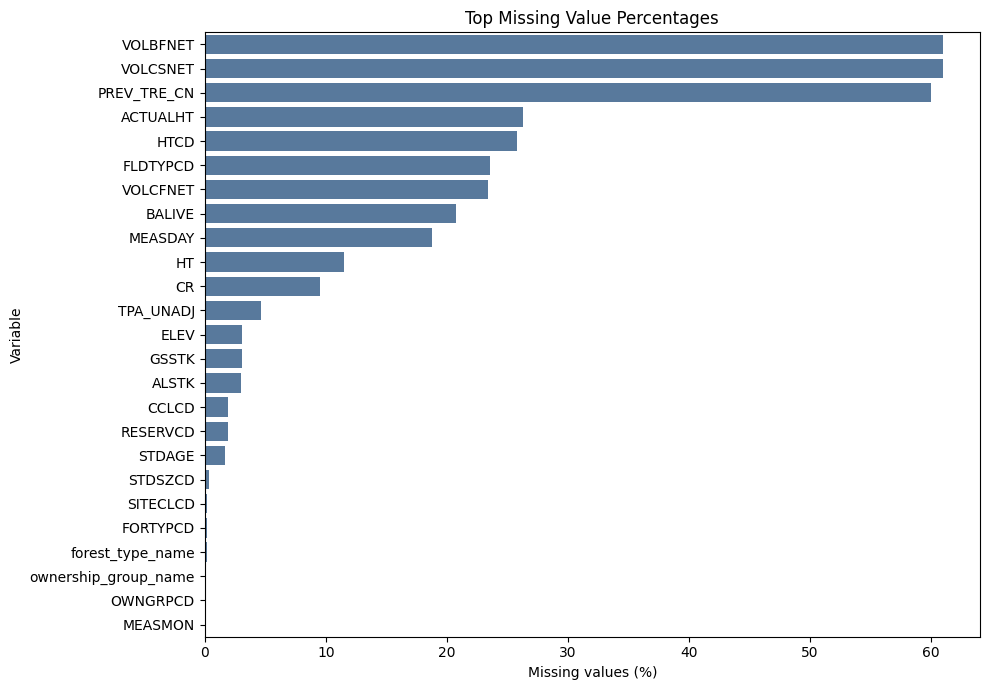

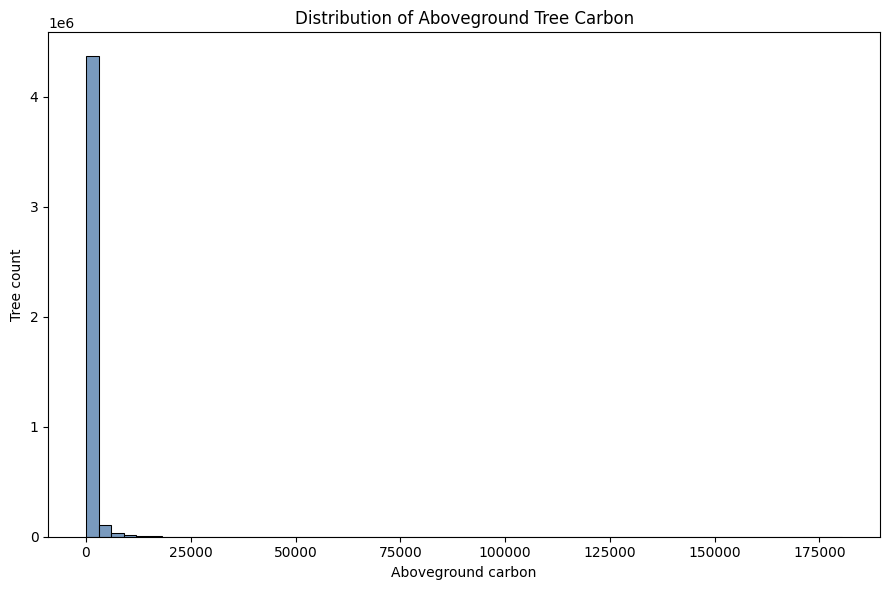

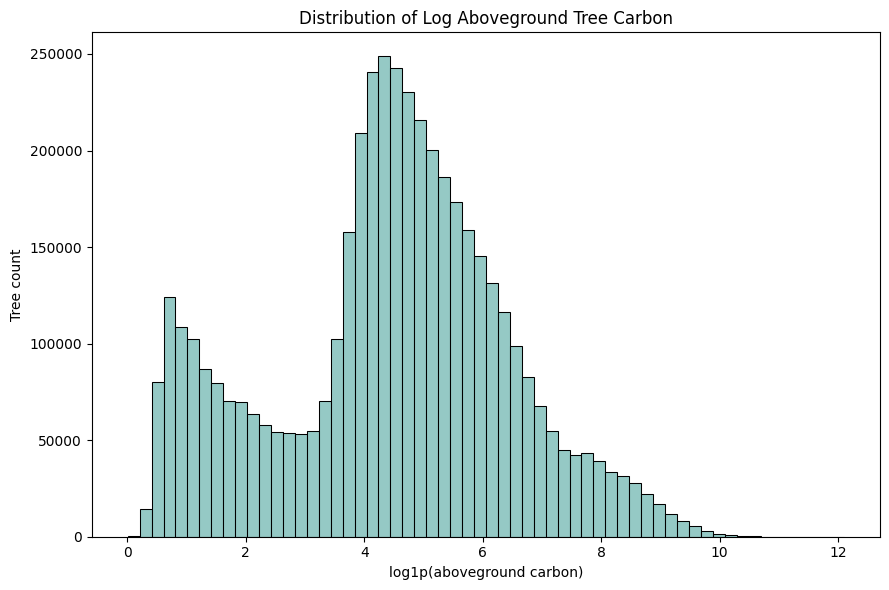

In [30]:
_ = plot_missing_values(df)
_ = plot_carbon_distribution(df)
_ = plot_log_carbon_distribution(df)



In [31]:
df["CARBON_AG_log"] = np.log1p(df["CARBON_AG"])

display(df["CARBON_AG"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame())
display(df["CARBON_AG_log"].describe().to_frame())



,CARBON_AG
count,4.540549e+06
mean,4.948008e+02
std,1.535001e+03
min,6.032000e-03
1%,6.516460e-01
5%,1.288325e+00
50%,9.649500e+01
95%,2.325179e+03
99%,7.391410e+03
max,1.804221e+05


,CARBON_AG_log
count,4.540549e+06
mean,4.442790e+00
std,1.997799e+00
min,6.013880e-03
25%,3.409262e+00
50%,4.579801e+00
75%,5.719265e+00
max,1.210306e+01


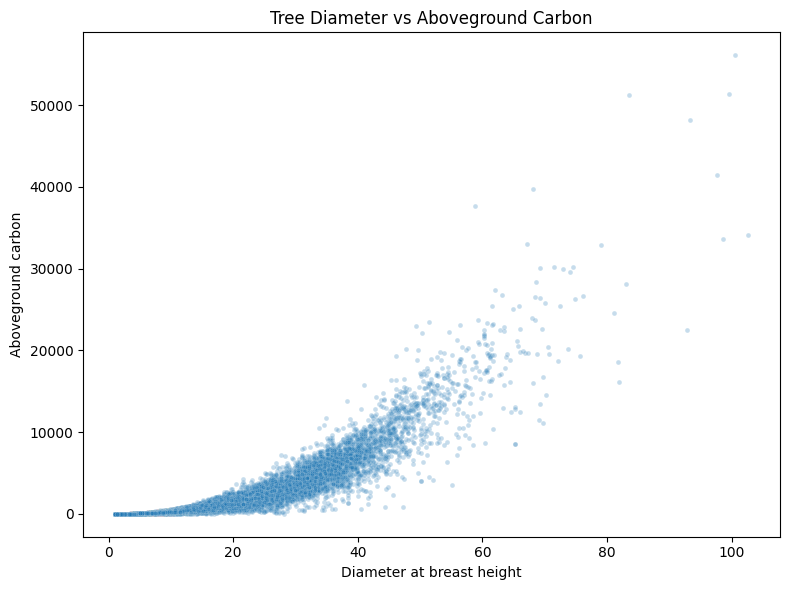

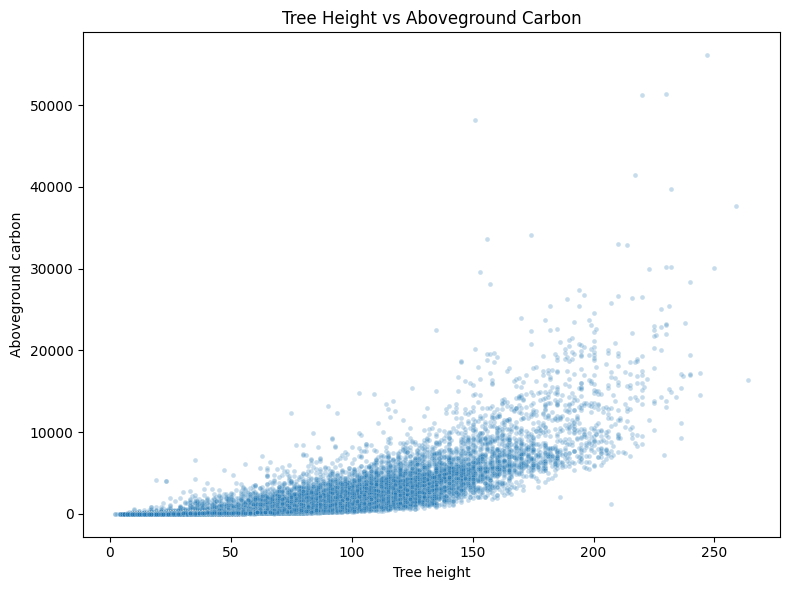

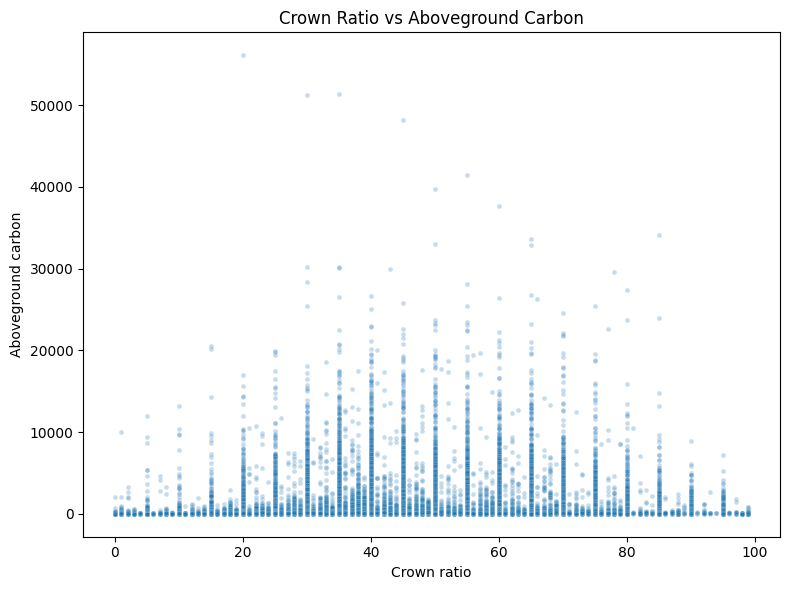

,DIA,HT,ACTUALHT,CR,CARBON_AG
DIA,1.000,0.860,0.845,0.115,0.827
HT,0.860,1.000,0.993,-0.058,0.706
ACTUALHT,0.845,0.993,1.000,-0.065,0.712
CR,0.115,-0.058,-0.065,1.000,0.069
CARBON_AG,0.827,0.706,0.712,0.069,1.000


In [32]:
_ = plot_dia_vs_carbon(eda_sample)
_ = plot_ht_vs_carbon(eda_sample)
if "CR" in df.columns:
    _ = plot_cr_vs_carbon(eda_sample)

df[[c for c in ["DIA", "HT", "ACTUALHT", "CR", "CARBON_AG"] if c in df.columns]].corr().round(3)



,diameter_class,count,mean,median
0,0-5,1207606,9.782475,4.165030
1,5-10,2044022,113.044586,93.533601
2,10-20,952807,573.822368,474.416191
3,20-30,188167,2285.789347,2189.606706
4,30-50,134901,5998.931111,5412.478056
5,50+,13046,16685.151358,15362.837803


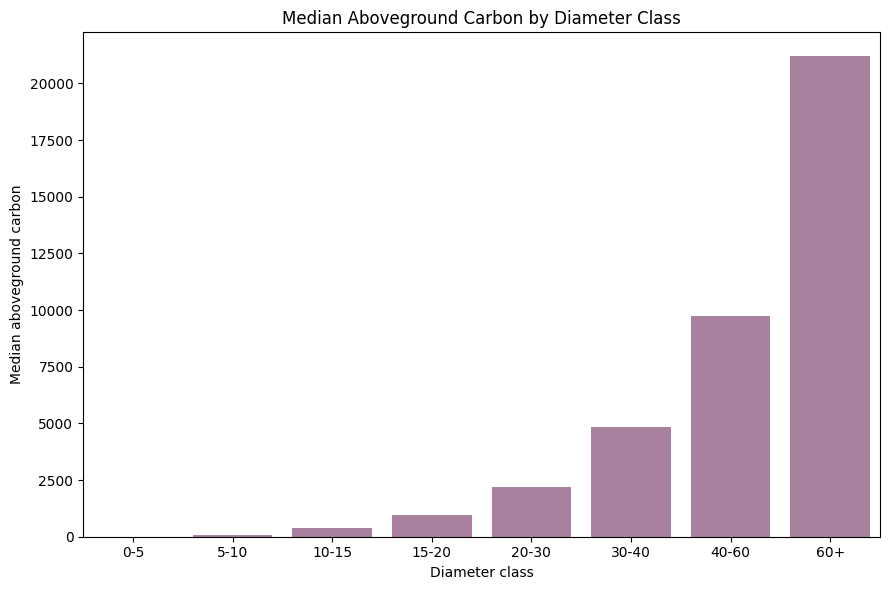

In [33]:
df["diameter_class"] = pd.cut(
    df["DIA"],
    bins=[0, 5, 10, 20, 30, 50, 1000],
    labels=["0-5", "5-10", "10-20", "20-30", "30-50", "50+"],
)

diameter_class_summary = (
    df.groupby("diameter_class", observed=True)["CARBON_AG"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(diameter_class_summary)
_ = plot_carbon_by_diameter_class(df)



,STATECD,tree_count,mean_carbon,median_carbon,min_carbon,max_carbon,state_name
2,13,1459434,238.928741,84.498648,0.200452,66875.541209,Georgia
0,1,854958,212.945623,79.491161,0.017175,16218.876788,Alabama
3,23,832606,124.832272,63.498006,0.006032,7742.190219,Maine
4,41,629090,1240.720286,200.213116,0.128792,97377.542504,Oregon
5,53,407671,940.141315,186.453892,0.186841,77959.239492,Washington
1,6,356790,1256.139226,196.108805,0.117182,180422.108817,California


,SPCD,tree_count,mean_carbon,median_carbon,min_carbon,max_carbon
60,131,594859,197.170444,90.549235,0.207023,8027.006938
66,202,378877,2008.862269,422.575060,0.162217,97377.542504
86,316,217297,140.194359,67.527053,0.049317,12947.535307
170,611,212315,151.341979,46.686121,0.241911,10382.810363
1,12,200280,45.482141,28.797305,0.059829,1075.510338
43,111,187008,209.730970,107.958337,0.418884,5905.760131
51,122,132460,1083.917954,261.834121,0.262305,36435.500904
78,263,110919,1028.346492,190.644999,0.240983,57907.166471
243,827,106628,268.774697,85.075916,0.406006,13372.629612
192,694,102550,198.785770,76.022295,0.532472,9000.102349


,FORTYPCD,tree_count,mean_carbon,median_carbon,min_carbon,max_carbon
14,161.0,721929,159.678306,73.281769,0.156876,21550.616331
26,201.0,443514,1518.189744,279.939787,0.160114,94161.416306
114,801.0,247417,156.400826,79.098409,0.006032,7742.190219
13,142.0,220542,173.026335,85.314064,0.274637,8398.223849
78,503.0,141475,289.577980,93.478098,0.032432,13178.261184
72,406.0,135723,209.356670,71.382463,0.207023,22922.879306
29,221.0,127529,811.570534,205.877915,0.184941,33721.072876
5,121.0,118849,67.441743,41.150070,0.084872,3781.261190
94,600.0,118815,371.982350,99.932027,0.449916,66875.541209
75,500.0,116853,327.439255,50.828583,0.385226,23729.667626


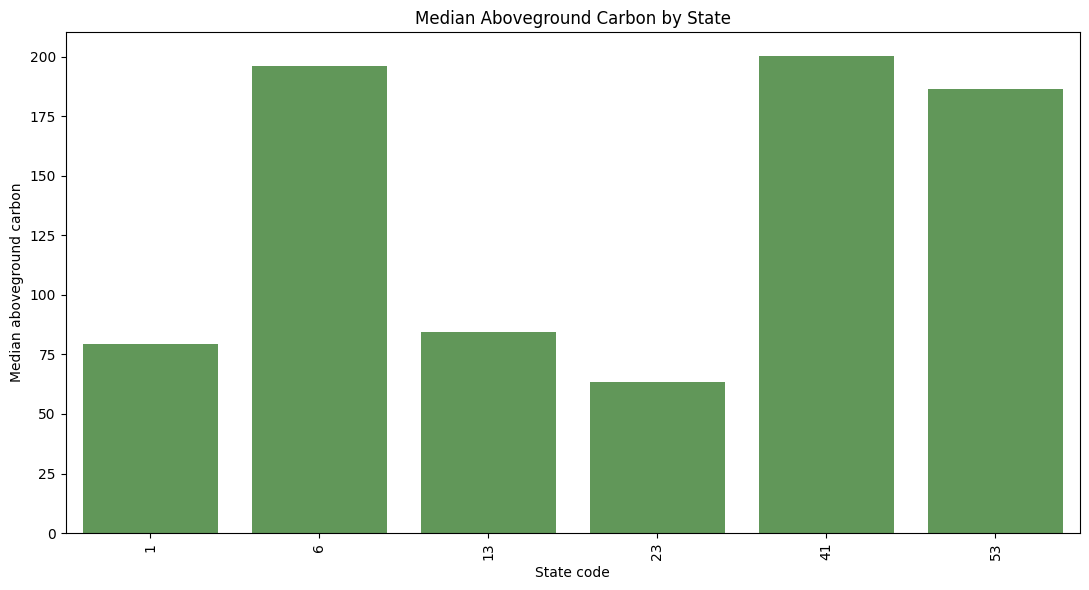

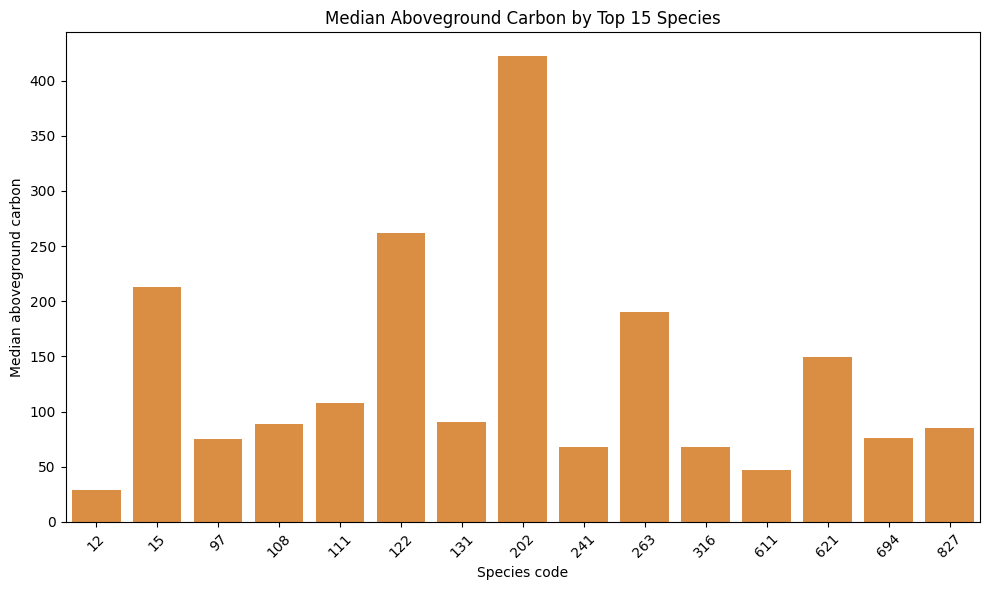

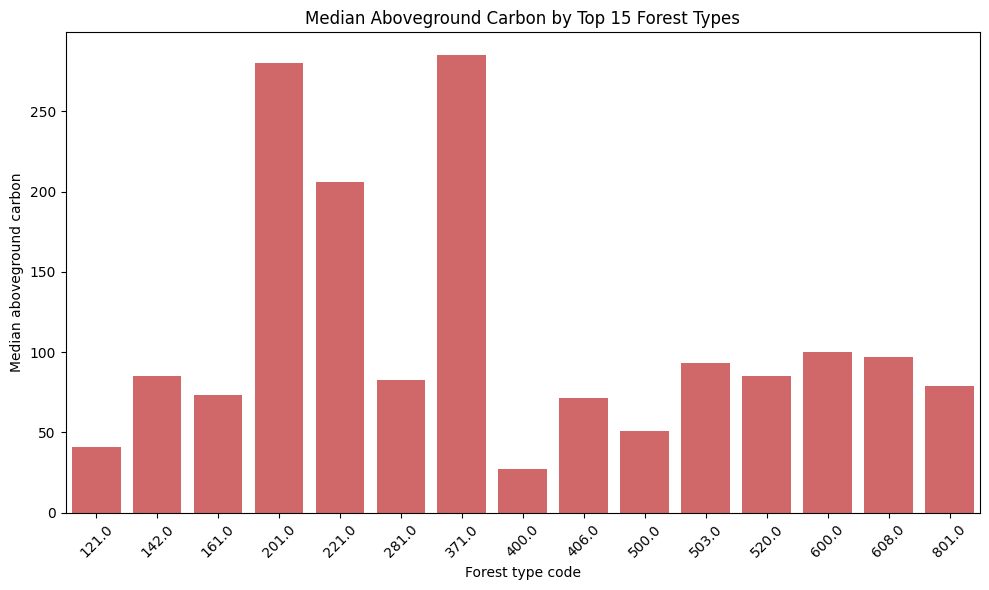

In [34]:
state_summary = create_state_summary(df, OUTPUTS_DIR / "eda_state_summary.csv")
if "STATECD" in state_summary.columns:
    state_summary["state_name"] = state_summary["STATECD"].map(state_code_to_name)

species_summary = create_species_summary(df, OUTPUTS_DIR / "eda_species_summary.csv")
forest_type_summary = create_forest_type_summary(df, OUTPUTS_DIR / "eda_forest_type_summary.csv")

display(state_summary)
display(species_summary.head(20))
display(forest_type_summary.head(20))

_ = plot_carbon_by_state(df)
_ = plot_carbon_by_top_species(df, top_n=15)
_ = plot_carbon_by_forest_type(df, top_n=15)



### Labelled species and forest type summaries

The existing EDA summaries use FIA numeric codes. The labelled summaries below provide more business-readable versions where the reference-table mappings are available.

In [35]:
if "species_name" in df.columns:
    top_species_labels = df["species_name"].value_counts().head(15).index

    eda_species_labelled_summary = (
        df[df["species_name"].isin(top_species_labels)]
        .groupby("species_name", observed=True)
        .agg(
            row_count=("CARBON_AG", "size"),
            median_CARBON_AG=("CARBON_AG", "median"),
            mean_CARBON_AG=("CARBON_AG", "mean"),
        )
        .reset_index()
        .sort_values("median_CARBON_AG", ascending=False)
    )

    eda_species_labelled_summary.to_csv(
        OUTPUTS_DIR / "eda_species_labelled_summary.csv",
        index=False,
    )

    display(eda_species_labelled_summary)
else:
    print("species_name column is not available.")

,species_name,row_count,median_CARBON_AG,mean_CARBON_AG
0,Douglas-fir,378877,422.575060,2008.862269
5,ponderosa pine,132460,261.834121,1083.917954
13,white fir,70657,212.796853,1305.728863
12,western hemlock,110919,190.644999,1028.346492
14,yellow-poplar,65856,149.659170,382.792366
8,slash pine,187008,107.958337,209.730970
2,loblolly pine,594859,90.549235,197.170444
3,lodgepole pine,98430,89.162542,255.674057
11,water oak,106628,85.075916,268.774697
9,swamp tupelo,102550,76.022295,198.785770


In [36]:
if "forest_type_name" in df.columns:
    top_forest_type_labels = df["forest_type_name"].value_counts().head(15).index

    eda_forest_type_labelled_summary = (
        df[df["forest_type_name"].isin(top_forest_type_labels)]
        .groupby("forest_type_name", observed=True)
        .agg(
            row_count=("CARBON_AG", "size"),
            median_CARBON_AG=("CARBON_AG", "median"),
            mean_CARBON_AG=("CARBON_AG", "mean"),
        )
        .reset_index()
        .sort_values("median_CARBON_AG", ascending=False)
    )

    eda_forest_type_labelled_summary.to_csv(
        OUTPUTS_DIR / "eda_forest_type_labelled_summary.csv",
        index=False,
    )

    display(eda_forest_type_labelled_summary)
else:
    print("forest_type_name column is not available.")

,forest_type_name,row_count,median_CARBON_AG,mean_CARBON_AG
1,California mixed conifer,111745,284.913330,1665.891914
2,Douglas-fir,443514,279.939787,1518.189744
10,Ponderosa pine,127529,205.877915,811.570534
7,Oak / gum / cypress group,118815,99.932027,371.982350
13,Sweetbay / swamp tupelo / red maple,95416,96.794733,208.840365
14,White oak / red oak / hickory,141475,93.478098,289.577980
11,Slash pine,220542,85.314064,173.026335
6,Mixed upland hardwoods,103365,84.866854,243.892245
5,Lodgepole pine,92309,82.676446,306.129540
12,Sugar maple / beech / yellow birch,247417,79.098409,156.400826


,CARBON_AG,DIA,HT,ACTUALHT,CR,STDAGE,BALIVE,ALSTK,GSSTK
CARBON_AG,1.000,0.827,0.706,0.712,0.069,0.394,0.271,-0.018,0.030
DIA,0.827,1.000,0.860,0.845,0.115,0.438,0.306,-0.071,-0.007
HT,0.706,0.860,1.000,0.993,-0.058,0.333,0.325,0.033,0.088
ACTUALHT,0.712,0.845,0.993,1.000,-0.065,0.330,0.320,0.080,0.140
CR,0.069,0.115,-0.058,-0.065,1.000,0.055,-0.095,-0.118,-0.108
STDAGE,0.394,0.438,0.333,0.330,0.055,1.000,0.385,-0.107,-0.036
BALIVE,0.271,0.306,0.325,0.320,-0.095,0.385,1.000,0.412,0.444
ALSTK,-0.018,-0.071,0.033,0.080,-0.118,-0.107,0.412,1.000,0.854
GSSTK,0.030,-0.007,0.088,0.140,-0.108,-0.036,0.444,0.854,1.000


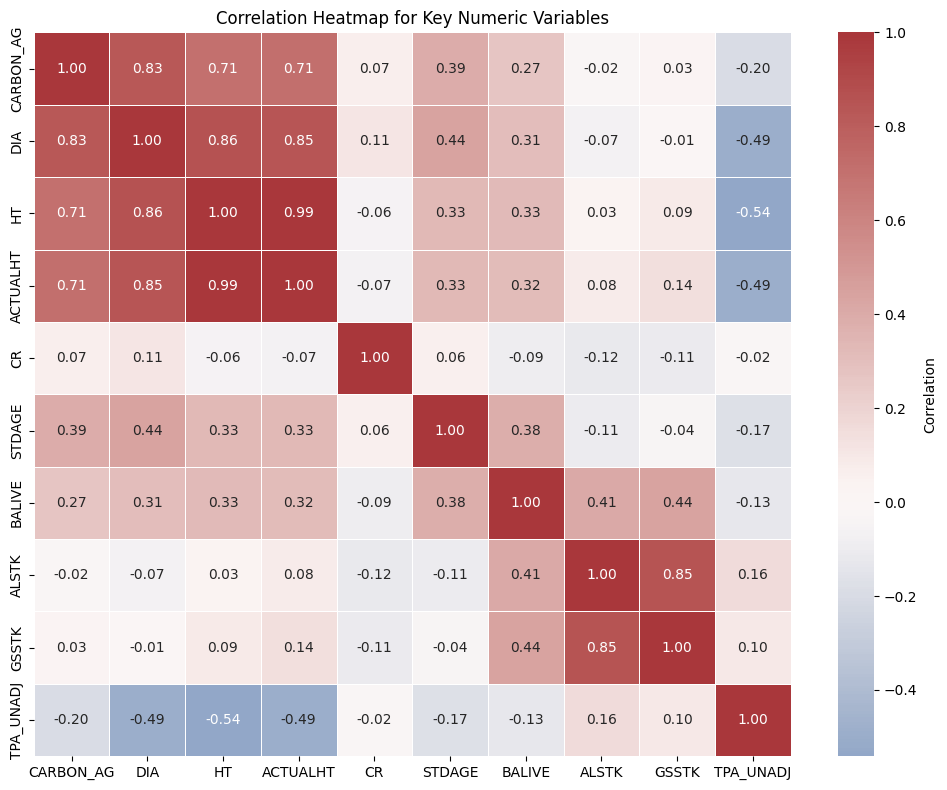

In [37]:
numeric_corr_cols = ["CARBON_AG", "DIA", "HT", "ACTUALHT", "CR", "STDAGE", "BALIVE", "ALSTK", "GSSTK"]
numeric_corr_cols = [c for c in numeric_corr_cols if c in df.columns]

display(df[numeric_corr_cols].corr().round(3))
_ = plot_correlation_heatmap(df)



### Additional log-scale EDA figures

The following plots support the outlier and distribution discussion for the report. They use `log1p(CARBON_AG)` because the raw target distribution is highly right-skewed.

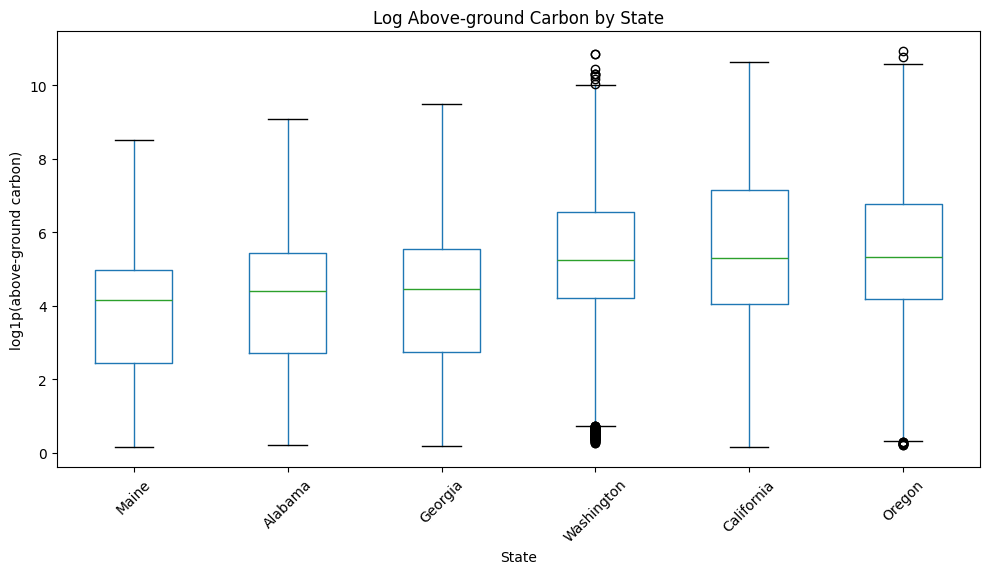

In [38]:
plot_df = eda_sample.dropna(subset=["CARBON_AG", "state_name"]).copy()
plot_df["CARBON_AG_log"] = np.log1p(plot_df["CARBON_AG"])

state_order = (
    plot_df.groupby("state_name")["CARBON_AG_log"]
    .median()
    .sort_values()
    .index
)

plot_df["state_name"] = pd.Categorical(
    plot_df["state_name"],
    categories=state_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.boxplot(
    column="CARBON_AG_log",
    by="state_name",
    ax=ax,
    grid=False,
    rot=45,
)

ax.set_title("Log Above-ground Carbon by State")
ax.set_xlabel("State")
ax.set_ylabel("log1p(above-ground carbon)")
fig.suptitle("")

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "log_carbon_boxplot_by_state.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

The log-scale boxplots and density-style histogram confirm that above-ground carbon is highly skewed in raw form but more interpretable after log transformation. The boxplots also show variation across states and diameter classes, supporting the use of both geographic and tree-size predictors in the modelling dataset. High-carbon observations were retained because they may represent genuinely large trees rather than data errors.

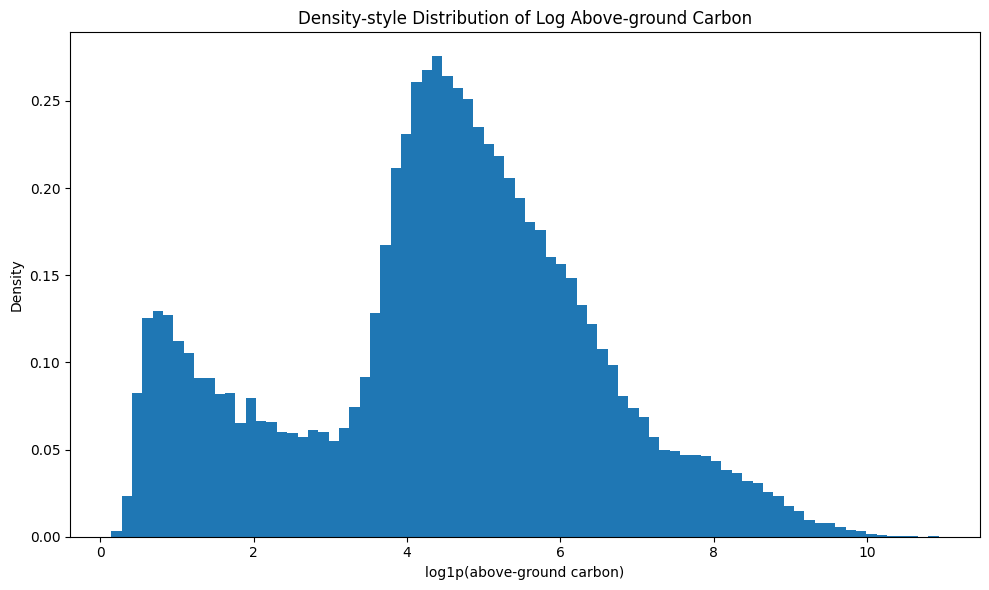

In [39]:
plot_df = eda_sample.dropna(subset=["CARBON_AG"]).copy()
plot_df["CARBON_AG_log"] = np.log1p(plot_df["CARBON_AG"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    plot_df["CARBON_AG_log"],
    bins=80,
    density=True,
)

ax.set_title("Density-style Distribution of Log Above-ground Carbon")
ax.set_xlabel("log1p(above-ground carbon)")
ax.set_ylabel("Density")

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "log_carbon_density_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

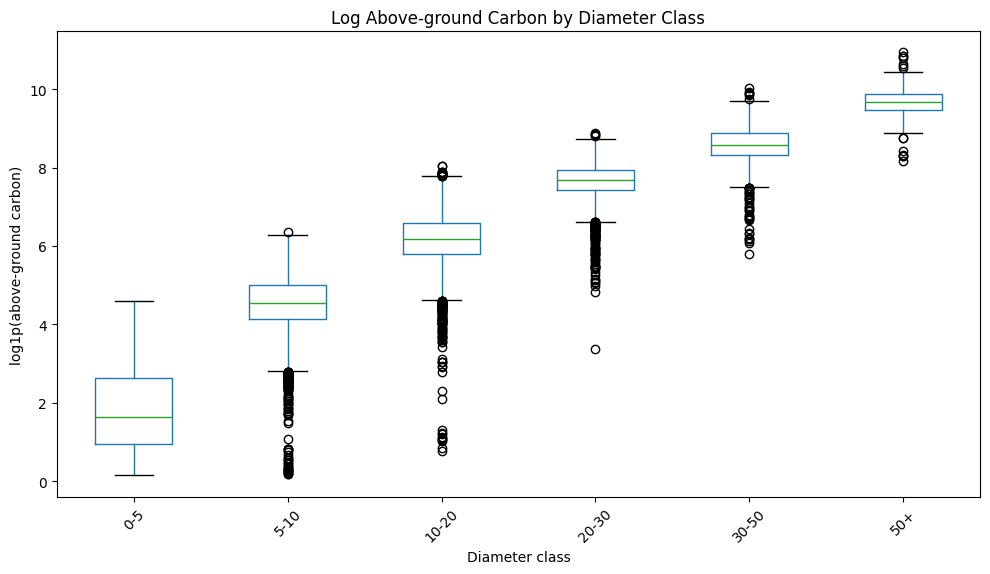

In [41]:
plot_df = eda_sample.dropna(subset=["CARBON_AG", "DIA"]).copy()
plot_df["CARBON_AG_log"] = np.log1p(plot_df["CARBON_AG"])

diameter_bins = [0, 5, 10, 20, 30, 50, np.inf]
diameter_order = ["0-5", "5-10", "10-20", "20-30", "30-50", "50+"]

plot_df["diameter_class"] = pd.cut(
    plot_df["DIA"],
    bins=diameter_bins,
    labels=diameter_order,
    include_lowest=True,
)

plot_df = plot_df.dropna(subset=["diameter_class"])

plot_df["diameter_class"] = pd.Categorical(
    plot_df["diameter_class"],
    categories=diameter_order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 6))

plot_df.boxplot(
    column="CARBON_AG_log",
    by="diameter_class",
    ax=ax,
    grid=False,
    rot=45,
)

ax.set_title("Log Above-ground Carbon by Diameter Class")
ax.set_xlabel("Diameter class")
ax.set_ylabel("log1p(above-ground carbon)")
fig.suptitle("")

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "log_carbon_boxplot_by_diameter_class.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [42]:
feature_decision_notes = pd.DataFrame([
    {"variable": "DIA", "decision": "Keep", "reason": "Strongest relationship with CARBON_AG and central tree-size predictor."},
    {"variable": "HT", "decision": "Keep or compare with ACTUALHT", "reason": "Strong relationship with carbon but highly correlated with ACTUALHT."},
    {"variable": "ACTUALHT", "decision": "Compare with HT", "reason": "Almost duplicate height information; may cause redundancy."},
    {"variable": "CR", "decision": "Optional", "reason": "Weak direct correlation but may capture tree condition."},
    {"variable": "SPCD", "decision": "Keep as categorical", "reason": "Species codes show different median carbon values."},
    {"variable": "STATECD", "decision": "Keep as categorical", "reason": "Selected states show different median carbon patterns."},
    {"variable": "COUNTYCD", "decision": "Keep as categorical", "reason": "County provides finer geographic context than state."},
    {"variable": "FORTYPCD", "decision": "Keep as categorical", "reason": "Forest type shows variation in median carbon."},
    {"variable": "OWNGRPCD", "decision": "Keep as categorical", "reason": "Ownership context may help explain management-related forest differences."},
    {"variable": "SITECLCD", "decision": "Keep as categorical", "reason": "Site productivity class may influence tree growth and carbon storage."},
    {"variable": "STDSZCD", "decision": "Keep as categorical", "reason": "Stand size class provides interpretable structural context."},
    {"variable": "VOLCFNET / VOLCSNET / VOLBFNET", "decision": "Drop from predictors", "reason": "High missingness and potential overlap with biomass/carbon estimation."},
    {"variable": "DRYBIO_AG", "decision": "Drop from predictors", "reason": "Directly related to carbon/biomass target and likely leakage risk."},
    {"variable": "DRYBIO_BG", "decision": "Drop from predictors", "reason": "Biomass-derived field and leakage risk."},
    {"variable": "CARBON_BG", "decision": "Drop from predictors", "reason": "Non-target carbon-derived field and leakage risk."},
    {"variable": "TPA_UNADJ", "decision": "Drop or treat cautiously", "reason": "Expansion factor/plot weighting field, not a direct tree characteristic for prediction."},
])

feature_decision_notes.to_csv(OUTPUTS_DIR / "eda_feature_decision_notes.csv", index=False)
feature_decision_notes



,variable,decision,reason
0,DIA,Keep,Strongest relationship with CARBON_AG and cent...
1,HT,Keep or compare with ACTUALHT,Strong relationship with carbon but highly cor...
2,ACTUALHT,Compare with HT,Almost duplicate height information; may cause...
3,CR,Optional,Weak direct correlation but may capture tree c...
4,SPCD,Keep as categorical,Species codes show different median carbon val...
5,STATECD,Keep as categorical,Selected states show different median carbon p...
6,COUNTYCD,Keep as categorical,County provides finer geographic context than ...
7,FORTYPCD,Keep as categorical,Forest type shows variation in median carbon.
8,OWNGRPCD,Keep as categorical,Ownership context may help explain management-...
9,SITECLCD,Keep as categorical,Site productivity class may influence tree gro...


### EDA interpretation for feature preparation

The final EDA confirms that above-ground tree carbon is highly right-skewed, with large trees contributing disproportionately to high carbon values. Diameter is the strongest individual predictor, while height also provides useful structural information. `HT` and `ACTUALHT` are highly correlated, so later modelling can compare whether both are useful or whether one is redundant.

Crown ratio has weaker direct correlation with `CARBON_AG`, but it remains a potentially useful secondary condition variable. State, species and forest type patterns show that carbon storage differs across geographic and ecological categories, supporting the retention of these variables as categorical predictors.

The EDA also supports the exclusion of biomass, volume and non-target carbon fields from predictors because these variables could inflate performance through leakage rather than providing genuinely usable decision-support features.

## 11. Final preprocessing and dataset split

        The final modelling dataset remains unencoded and unscaled. `CARBON_AG` is the main target, while `CARBON_AG_log` is retained only as an optional transformed target.


In [43]:
df_clean = pd.read_parquet(INTERIM_DIR / "fia_tree_carbon_clean_unencoded.parquet")
df_engineered = create_engineered_features(df_clean)

(
    model_df,
    numeric_features,
    categorical_features,
    id_columns,
    target_columns,
    dropped_leakage_columns,
) = select_final_model_columns(df_engineered)

print("Model dataset shape:", model_df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("ID/context columns:", id_columns)
print("Target columns:", target_columns)
print("Dropped leakage-risk columns:", dropped_leakage_columns)



Engineered features created.
Leakage-risk columns excluded: 7
Selected modelling dataset shape: (4540549, 24)
Numeric features: 10
Categorical features: 8
Model dataset shape: (4540549, 24)
Numeric features: ['DIA', 'HT', 'ACTUALHT', 'CR', 'STDAGE', 'BALIVE', 'ALSTK', 'GSSTK', 'DIA_squared', 'DIA_HT_interaction']
Categorical features: ['SPCD', 'STATECD', 'COUNTYCD', 'FORTYPCD', 'OWNGRPCD', 'SITECLCD', 'STDSZCD', 'diameter_class']
ID/context columns: ['CN', 'PLT_CN', 'CONDID', 'TREE']
Target columns: ['CARBON_AG', 'CARBON_AG_log']
Dropped leakage-risk columns: ['CARBON_BG', 'DRYBIO_AG', 'DRYBIO_BG', 'TPA_UNADJ', 'VOLBFNET', 'VOLCFNET', 'VOLCSNET']


In [44]:
leakage_terms = ["DRYBIO", "VOL", "CARBON_BG"]

leakage_still_present = [
    c for c in model_df.columns
    if any(term in c.upper() for term in leakage_terms)
]

target_predictor_overlap = [
    c for c in target_columns
    if c in numeric_features or c in categorical_features
]

print("Leakage-risk columns still present:", leakage_still_present)
print("Target columns:", target_columns)
print("Target columns also listed as predictors:", target_predictor_overlap)
print("Target columns present in model_df:", [c for c in target_columns if c in model_df.columns])
print("CARBON_AG_log in dropped leakage columns:", "CARBON_AG_log" in dropped_leakage_columns)

if leakage_still_present:
    raise ValueError("Leakage-risk columns remain in model_df.")
if target_predictor_overlap:
    raise ValueError("Target columns are listed as predictors.")
if "CARBON_AG_log" in dropped_leakage_columns:
    raise ValueError("CARBON_AG_log should be retained as an optional transformed target, not dropped as leakage.")



Leakage-risk columns still present: []
Target columns: ['CARBON_AG', 'CARBON_AG_log']
Target columns also listed as predictors: []
Target columns present in model_df: ['CARBON_AG', 'CARBON_AG_log']
CARBON_AG_log in dropped leakage columns: False


In [45]:
selected_missing = (
    model_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
selected_missing.columns = ["variable", "missing_percentage"]
selected_missing



,variable,missing_percentage
0,ACTUALHT,26.296203
1,BALIVE,20.747579
2,HT,11.506076
3,DIA_HT_interaction,11.506076
4,CR,9.509401
5,GSSTK,3.045469
6,ALSTK,2.988097
7,STDAGE,1.701975
8,STDSZCD,0.378897
9,SITECLCD,0.152603


In [46]:
target_checks = {
    "rows": len(model_df),
    "missing_CARBON_AG": model_df["CARBON_AG"].isna().sum(),
    "negative_CARBON_AG": (model_df["CARBON_AG"] < 0).sum(),
    "zero_CARBON_AG": (model_df["CARBON_AG"] == 0).sum(),
    "min_CARBON_AG": model_df["CARBON_AG"].min(),
    "median_CARBON_AG": model_df["CARBON_AG"].median(),
    "mean_CARBON_AG": model_df["CARBON_AG"].mean(),
    "max_CARBON_AG": model_df["CARBON_AG"].max(),
}

pd.DataFrame(list(target_checks.items()), columns=["check", "value"])



,check,value
0,rows,4.540549e+06
1,missing_CARBON_AG,0.000000e+00
2,negative_CARBON_AG,0.000000e+00
3,zero_CARBON_AG,0.000000e+00
4,min_CARBON_AG,6.032000e-03
5,median_CARBON_AG,9.649500e+01
6,mean_CARBON_AG,4.948008e+02
7,max_CARBON_AG,1.804221e+05


In [47]:
train_df, validation_df, test_df, split_summary = create_stratified_regression_split(
    model_df,
    target_col="CARBON_AG",
    random_state=42,
)

split_summary



Created stratified train/validation/test split.
Train rows: 3,178,384
Validation rows: 681,082
Test rows: 681,083


,split,row_count,percentage,target_mean,target_median,target_min,target_max
0,full,4540549,100.000000,494.800823,96.494999,0.006032,180422.108817
1,train,3178384,69.999993,494.492902,96.493948,0.006032,164746.908386
2,validation,681082,14.999992,493.985571,96.495344,0.011980,123412.419611
3,test,681083,15.000014,497.053036,96.497961,0.017175,180422.108817


In [48]:
split_total = len(train_df) + len(validation_df) + len(test_df)
print("Model rows:", len(model_df))
print("Split total:", split_total)
print("Difference:", split_total - len(model_df))

if split_total != len(model_df):
    raise ValueError("Train, validation and test splits do not sum to the full model dataset.")

target_split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_df), "target_mean": train_df["CARBON_AG"].mean(), "target_median": train_df["CARBON_AG"].median(), "target_min": train_df["CARBON_AG"].min(), "target_max": train_df["CARBON_AG"].max()},
    {"split": "validation", "rows": len(validation_df), "target_mean": validation_df["CARBON_AG"].mean(), "target_median": validation_df["CARBON_AG"].median(), "target_min": validation_df["CARBON_AG"].min(), "target_max": validation_df["CARBON_AG"].max()},
    {"split": "test", "rows": len(test_df), "target_mean": test_df["CARBON_AG"].mean(), "target_median": test_df["CARBON_AG"].median(), "target_min": test_df["CARBON_AG"].min(), "target_max": test_df["CARBON_AG"].max()},
])

target_split_summary.to_csv(OUTPUTS_DIR / "final_target_split_summary.csv", index=False)
target_split_summary



Model rows: 4540549
Split total: 4540549
Difference: 0


,split,rows,target_mean,target_median,target_min,target_max
0,train,3178384,494.492902,96.493948,0.006032,164746.908386
1,validation,681082,493.985571,96.495344,0.011980,123412.419611
2,test,681083,497.053036,96.497961,0.017175,180422.108817


## 12. Save final modelling datasets and documentation


In [49]:
final_data_dictionary = create_final_data_dictionary(
    model_df=model_df,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    id_columns=id_columns,
    target_columns=target_columns,
)

final_feature_list = pd.DataFrame([
    {"variable": c, "feature_type": "numeric", "use_in_modelling": "Yes"} for c in numeric_features
] + [
    {"variable": c, "feature_type": "categorical", "use_in_modelling": "Yes"} for c in categorical_features
] + [
    {"variable": c, "feature_type": "identifier/context", "use_in_modelling": "No"} for c in id_columns
] + [
    {"variable": c, "feature_type": "target", "use_in_modelling": "Target only"} for c in target_columns
])

display(final_data_dictionary)
display(final_feature_list)



,variable_name,role,type,description
0,CARBON_AG,target,float64,Aboveground tree carbon target.
1,CARBON_AG_log,target,float64,Log-transformed aboveground carbon target usin...
2,CN,identifier/context,int64,Unique tree record identifier.
3,PLT_CN,identifier/context,int64,Plot identifier used to link TREE records to P...
4,CONDID,identifier/context,int64,Condition identifier within a plot.
5,TREE,identifier/context,int64,Tree number within a plot.
6,DIA,numeric_predictor,float64,Tree diameter at breast height.
7,HT,numeric_predictor,float64,Tree height.
8,ACTUALHT,numeric_predictor,float64,Actual measured tree height when available.
9,CR,numeric_predictor,float64,Crown ratio.


,variable,feature_type,use_in_modelling
0,DIA,numeric,Yes
1,HT,numeric,Yes
2,ACTUALHT,numeric,Yes
3,CR,numeric,Yes
4,STDAGE,numeric,Yes
5,BALIVE,numeric,Yes
6,ALSTK,numeric,Yes
7,GSSTK,numeric,Yes
8,DIA_squared,numeric,Yes
9,DIA_HT_interaction,numeric,Yes


In [50]:
save_preprocessing_outputs(
    model_df=model_df,
    train_df=train_df,
    validation_df=validation_df,
    test_df=test_df,
    data_dictionary=final_data_dictionary,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    id_columns=id_columns,
    target_columns=target_columns,
    dropped_leakage_columns=dropped_leakage_columns,
)

final_feature_list.to_csv(OUTPUTS_DIR / "final_feature_list.csv", index=False)
split_summary.to_csv(OUTPUTS_DIR / "final_split_summary.csv", index=False)
target_split_summary.to_csv(OUTPUTS_DIR / "final_target_split_summary.csv", index=False)

print("Saved full model dataset:", PROCESSED_DIR / "fia_model_data.parquet")
print("Saved train dataset:", PROCESSED_DIR / "fia_train.parquet")
print("Saved validation dataset:", PROCESSED_DIR / "fia_validation.parquet")
print("Saved test dataset:", PROCESSED_DIR / "fia_test.parquet")
print("Saved handoff notes:", OUTPUTS_DIR / "modelling_handoff_notes.txt")



Full modelling dataset saved to E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_model_data.parquet
Train split saved to E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_train.parquet
Validation split saved to E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_validation.parquet
Test split saved to E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_test.parquet
Saved full model dataset: E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_model_data.parquet
Saved train dataset: E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_train.parquet
Saved validation dataset: E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_validation.parquet
Saved test dataset: E:\BA_DV_Project\COMM074_FIA_Project\data\processed\fia_test.parquet
Saved handoff notes: E:\BA_DV_Project\COMM074_FIA_Project\outputs\modelling_handoff_notes.txt


Some categorical predictors, especially `SPCD` and `COUNTYCD`, may create many encoded columns if one-hot encoding is used. Individual modelling notebooks should consider memory constraints. All encoding decisions should be fitted on training data only to avoid leakage.


## 13. Verify saved processed outputs


In [51]:
expected_processed_files = [
    "fia_model_data.parquet",
    "fia_train.parquet",
    "fia_validation.parquet",
    "fia_test.parquet",
]

for file in expected_processed_files:
    path = PROCESSED_DIR / file
    print(file, "FOUND" if path.exists() else "MISSING")



fia_model_data.parquet FOUND
fia_train.parquet FOUND
fia_validation.parquet FOUND
fia_test.parquet FOUND


In [52]:
expected_output_files = [
    "final_feature_list.csv",
    "final_data_dictionary.csv",
    "final_split_summary.csv",
    "final_preprocessing_summary.csv",
    "final_target_split_summary.csv",
    "modelling_handoff_notes.txt",
]

for file in expected_output_files:
    path = OUTPUTS_DIR / file
    print(file, "FOUND" if path.exists() else "MISSING")



final_feature_list.csv FOUND
final_data_dictionary.csv FOUND
final_split_summary.csv FOUND
final_preprocessing_summary.csv FOUND
final_target_split_summary.csv FOUND
modelling_handoff_notes.txt FOUND


In [53]:
train_reload = pd.read_parquet(PROCESSED_DIR / "fia_train.parquet")
validation_reload = pd.read_parquet(PROCESSED_DIR / "fia_validation.parquet")
test_reload = pd.read_parquet(PROCESSED_DIR / "fia_test.parquet")

print("Reloaded train:", train_reload.shape)
print("Reloaded validation:", validation_reload.shape)
print("Reloaded test:", test_reload.shape)



Reloaded train: (3178384, 24)
Reloaded validation: (681082, 24)
Reloaded test: (681083, 24)


## 14. Submission summary

This notebook consolidates the full Section 1 and Section 2 workflow for the FIA tree carbon storage prediction project. It inventories the raw FIA DataMart files, selects the core TREE/PLOT/COND and reference tables, extracts the selected-state proof-of-concept dataset, and saves the extracted tables as Parquet files.

The TREE, PLOT and COND tables are merged into one tree-level dataset while preserving the original TREE row count. The merged data is cleaned by removing unusable target records, invalid diameter records, missing species records, non-live trees and exact duplicates. Coded missing values such as `STDAGE = -999` are converted to `NaN` before saving the cleaned unencoded dataset.

EDA confirms that `CARBON_AG` is highly right-skewed, `DIA` is the strongest observed predictor, `HT` and `ACTUALHT` are highly correlated, and state/species/forest type differences support retaining categorical predictors. Additional log-scale plots were created to support the outlier and distribution discussion in the report, and readable label mappings were added where reference tables were available.

The final modelling-ready dataset keeps `CARBON_AG` as the main target and `CARBON_AG_log` only as an optional transformed target. Biomass, volume and non-target carbon variables are removed from the predictor set. The final train, validation and test datasets are saved using a 70/15/15 structure for later modelling notebooks.

Key saved outputs from this notebook are:

- `outputs/eda_label_coverage_summary.csv`
- `outputs/eda_species_labelled_summary.csv`
- `outputs/eda_forest_type_labelled_summary.csv`
- `figures/log_carbon_boxplot_by_state.png`
- `figures/log_carbon_boxplot_by_diameter_class.png`
- `figures/log_carbon_density_distribution.png`